Chapter 1: Data Visualization with ggplot2

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning messages:
1: package ‘tidyverse’ was built under R version 4.5.2 
2: package ‘ggplot2’ was built under R version 4.5.2 
3: package ‘tidyr’ was built under R version 4.5.2 
4: package ‘purrr’ was built under R version 4.5.2 
5: package ‘dplyr’ was built under R version 4.5.2 
6: package ‘forcats’ was built under R version 4.5.2 
7: package ‘lubridate’ was built under R version 4.5.2 


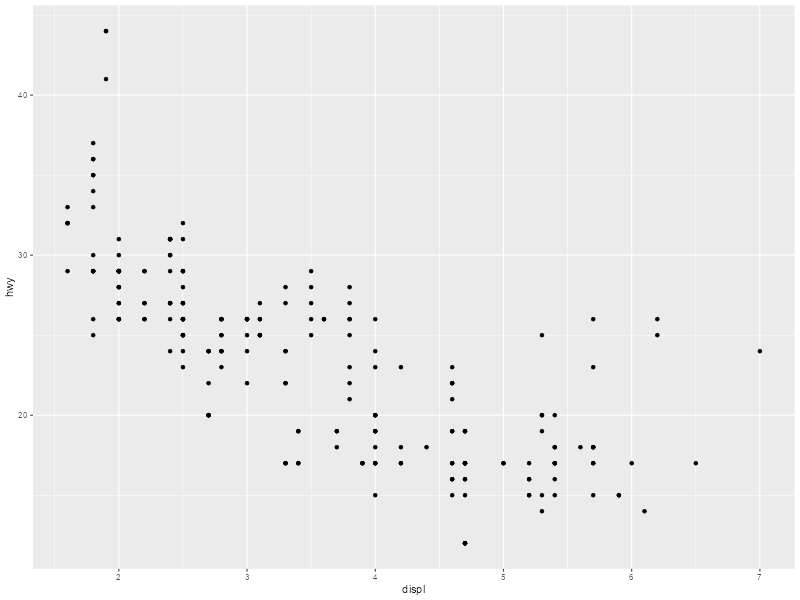

In [5]:
ggplot(data = mpg) + 
  geom_point(mapping = aes(x = displ, y=hwy))

In [12]:
nrow(mtcars)


[1] 32

In [15]:
?mpg

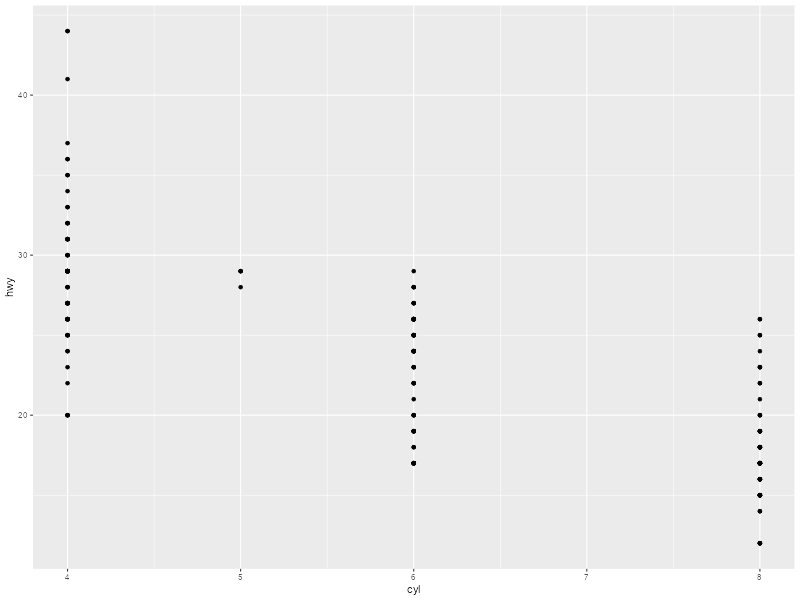

In [16]:
ggplot (data = mpg) +
  geom_point(mapping = aes(x = cyl, y = hwy))

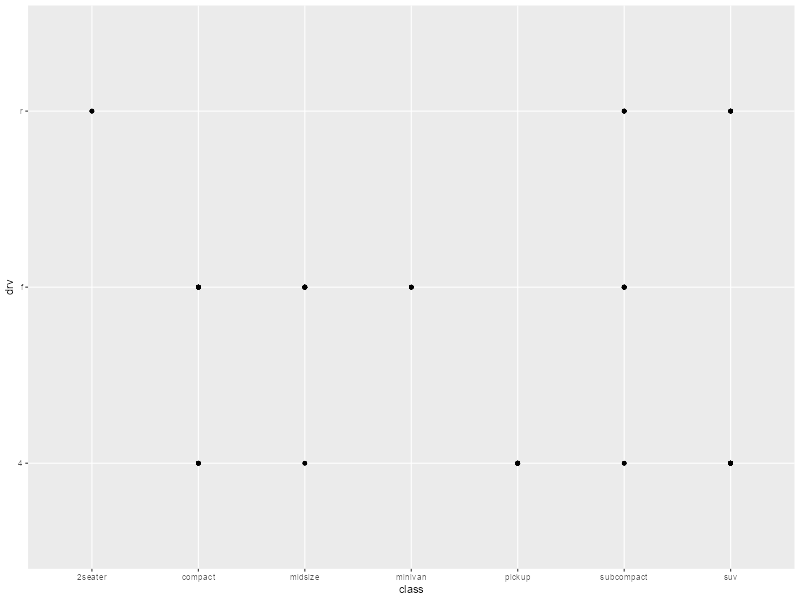

In [17]:
ggplot( data = mpg) +
  geom_point(mapping = aes(x=class, y= drv))

EXERSIZES
1) Run ggplot(data = mpg). What do you see?
    - I see a clear negative relationship between engine size and highway fuel efficiency.
    - Neither fuel efficiency nor engine size appear continuous in this datset. 
2) How many rows are in mtcars? How many columns?
    - There are 32 rows and 11 columns in mtcars
3) What does the drv variable describe?
    - drv describes the type of driver train, where f = front-wheel, r = rear wheel, 4 = 4 way drive
4) Make a scatterplot of hwy vs cyl 
    - See above
5) What happens if you make a scatterplot of class versus drv? Why is the plot not useful?
    - The plot is not useful as neither drv or class are numeric. Additionally, you are not able to see the number of vehicles in each class and drive train.

Aesthetic Mappings

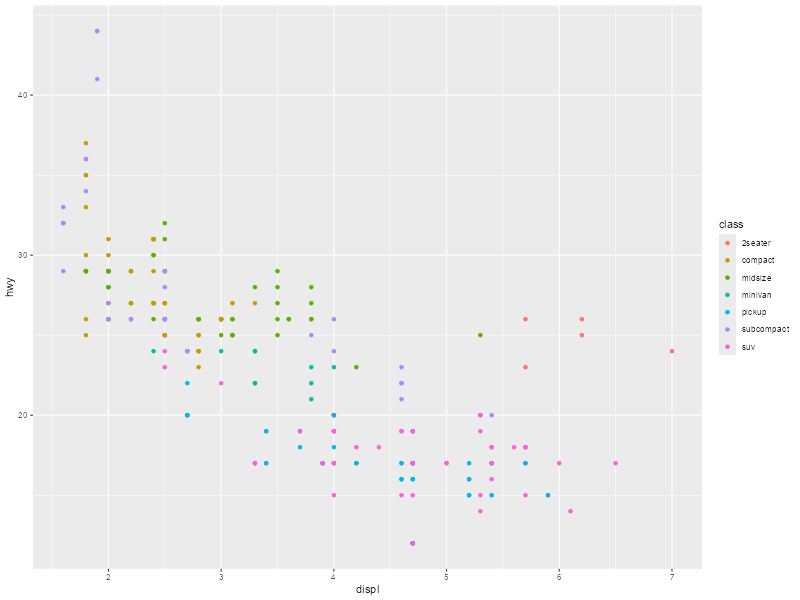

In [18]:
ggplot(data = mpg) +
  geom_point(mapping = aes(x = displ, y = hwy, color = class))

Exercises

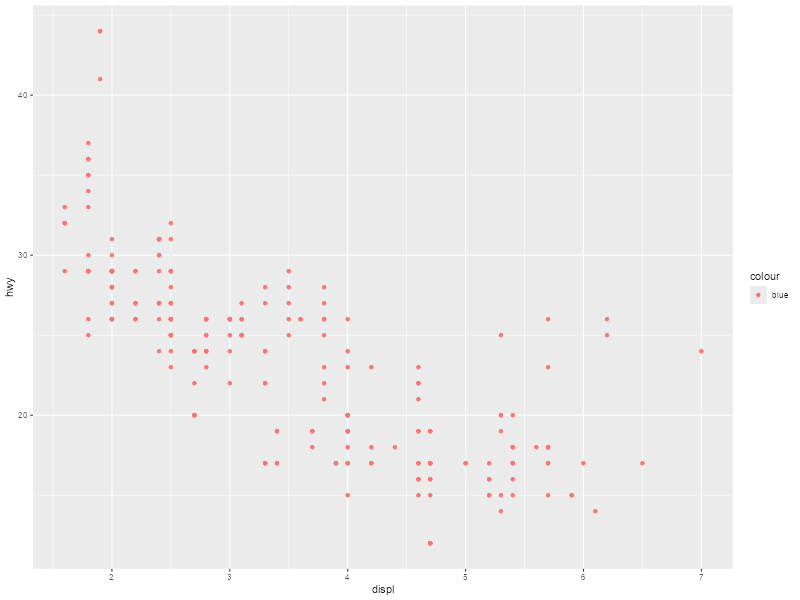

In [22]:
#What's wrong with this code? Why are the points not blue?
ggplot(data = mpg) + 
  geom_point(
    mapping = aes(x = displ, y = hwy, color = 'blue')
  )
#The problem with this code is that blue is on the inside of aes, so it is looking for a 'blue' variable that doesn't exist. 

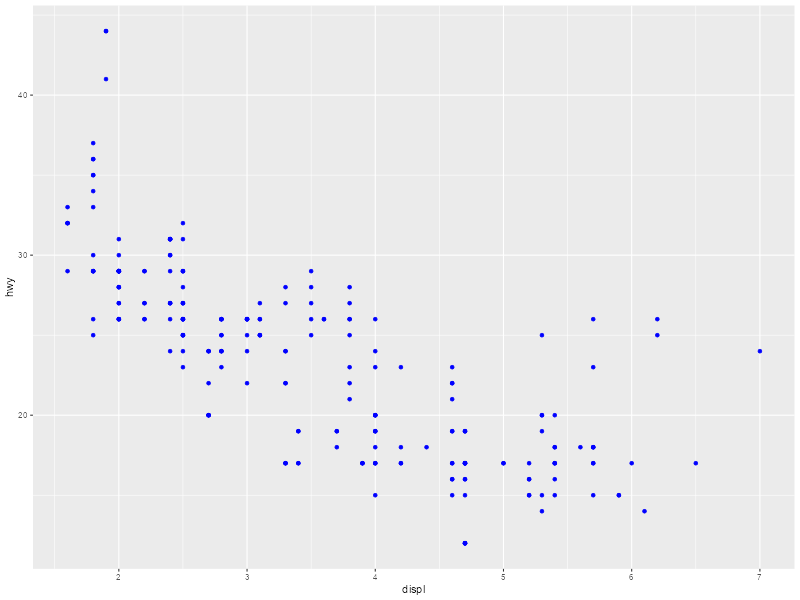

In [23]:
#This is what the correct code looks like
ggplot(data = mpg) + 
  geom_point(mapping = aes(x = displ, y = hwy), color = 'blue')

In [25]:
#Exercise 2: Which variables in mpg are categorical? Which variables are continuous?
?mpg
#Manufacturer, model, year, trans, drv, fl, and class are categorical (some are numeric, but still categorical)
#displ, cty, and hwy are continuous.

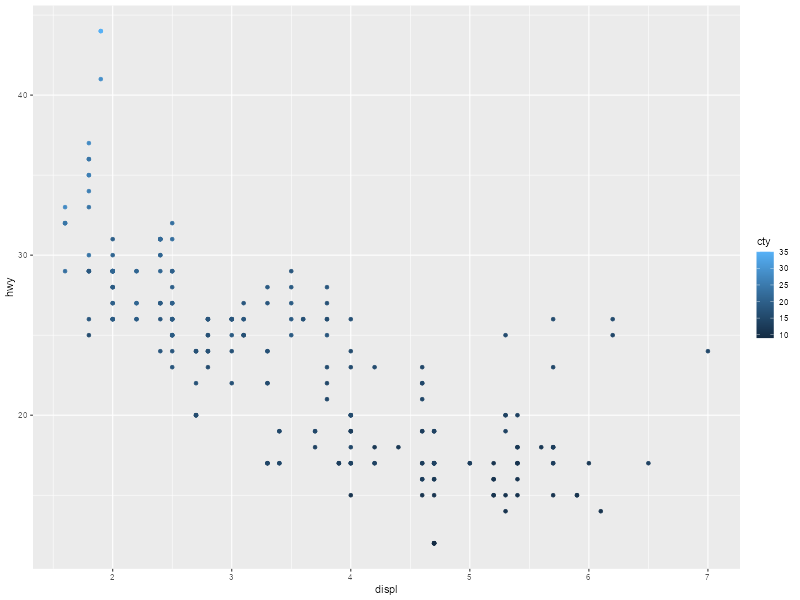

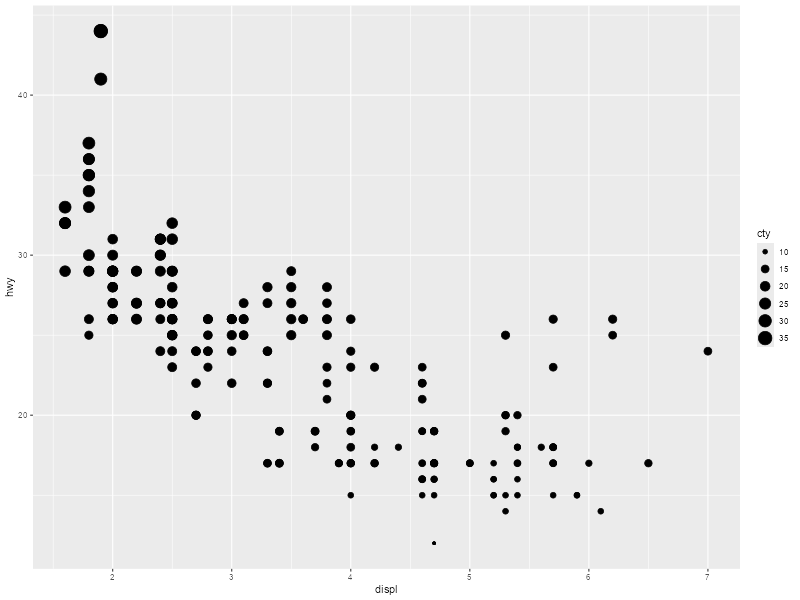

: [1m[33mError[39m in `geom_point()`:[22m
[1m[22m[33m![39m Problem while computing aesthetics.
[36mℹ[39m Error occurred in the 1st layer.
[1mCaused by error in `scale_f()`:[22m
[1m[22m[33m![39m A continuous variable cannot be mapped to the [32mshape[39m aesthetic.
[36mℹ[39m Choose a different aesthetic or use `scale_shape_binned()`.

In [ ]:
#3 Map a continous variable to color, size, and shape. How do these aesthetics behave different for categorical variables vs. continous variables?
ggplot(data=mpg) +
  geom_point(mapping = aes(x = displ, y =hwy, color = cty))
ggplot(data=mpg) +
  geom_point(mapping = aes(x = displ, y =hwy, size = cty))
ggplot(data=mpg) +
  geom_point(mapping = aes(x = displ, y =hwy, shape = cty))
#Color uses a gradient, larger values have a larger size, and shape does not work with continuous variables. 

Warning message:
Using size for a discrete variable is not advised. 


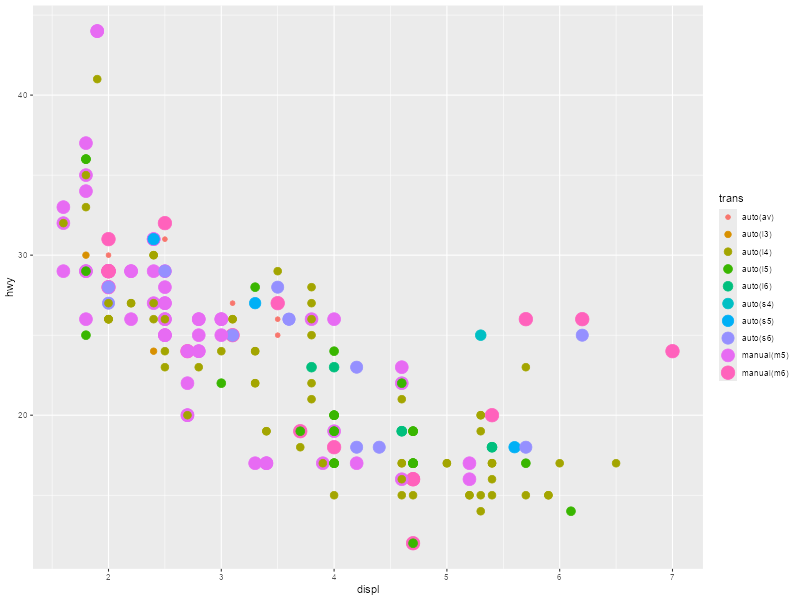

In [ ]:
#Exercise 4: What happens if you map the same variable to multiple aesthetics?
ggplot(data=mpg) +
  geom_point(mapping = aes(x=displ, y = hwy, color = trans, size = trans))
#When you map the same variable to multiple aesthetics, it uses both to distinguish different values. In this example, each type of transmission has a
#different color and size

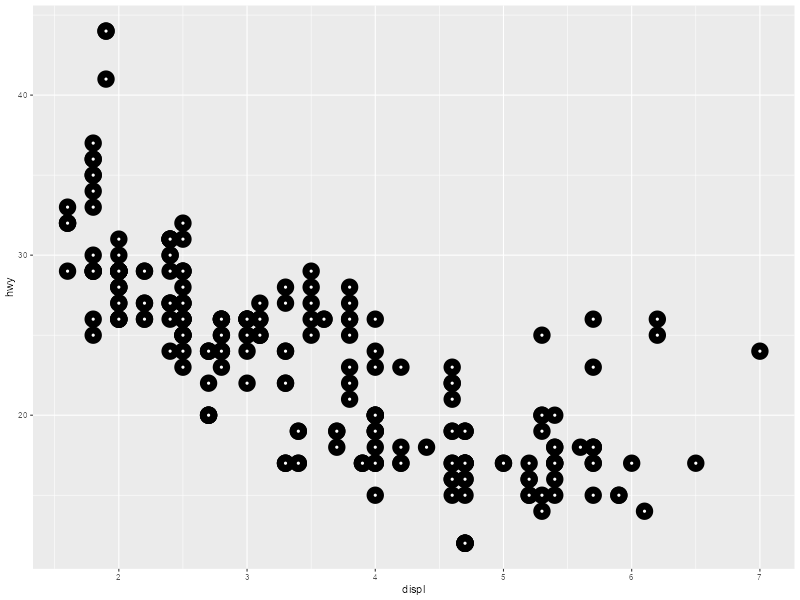

In [37]:
#Exercise 5: What does the stroke aesthetic do? What shape does it work with?
ggplot(data = mpg) +
  geom_point(mapping = aes(x=displ, y=hwy), shape =21,  color = 'black', fill = 'white',stroke = 5)
#Stroke determines the size of the border of a symbol

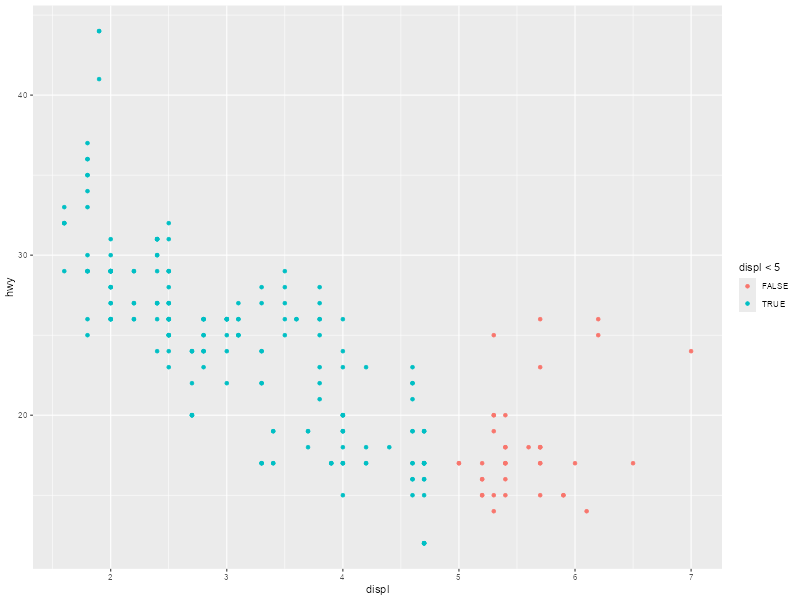

In [ ]:
#Exercise 6: What happens if you map an aesthetic to do something other than a variable name, like aes(color = displ<5)?
ggplot(data = mpg) +
  geom_point(mapping = aes(x = displ, y = hwy, color = displ<5))
#It uses different colors depending on whether the argument is true or false

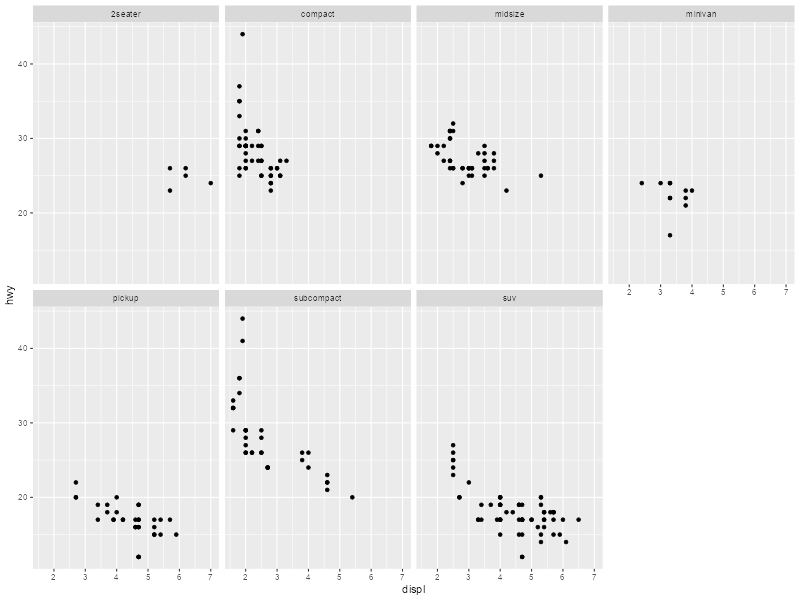

In [40]:
ggplot( data = mpg)+ 
  geom_point(mapping = aes(x = displ, y = hwy)) + #X and Y
  facet_wrap(~ class, nrow = 2) #One graph per class, 2 rows

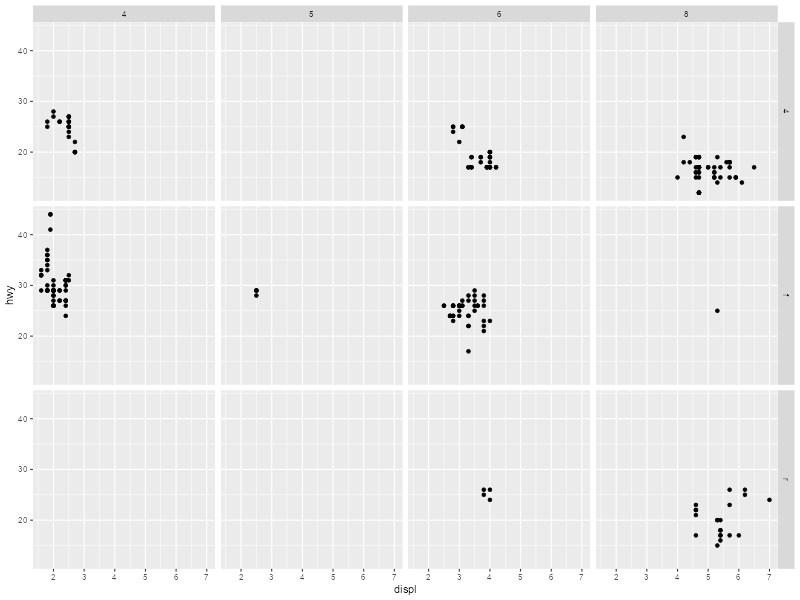

In [ ]:
ggplot(data = mpg) +
  geom_point(mapping = aes(x = displ, y = hwy))+
  facet_grid(drv ~ cyl) #cylinders on x, drv on y

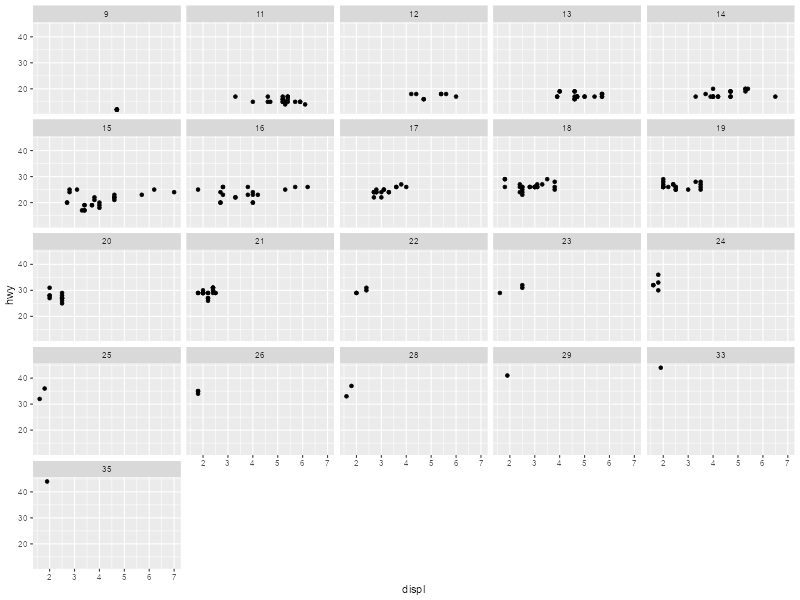

In [43]:
#Exercise 1: What happens if you facet on a continous variable?
ggplot(data = mpg)+
  geom_point(mapping = aes(x = displ, y = hwy))+
  facet_wrap(~cty) 
#It divides the facets into different chunks of the continous variable

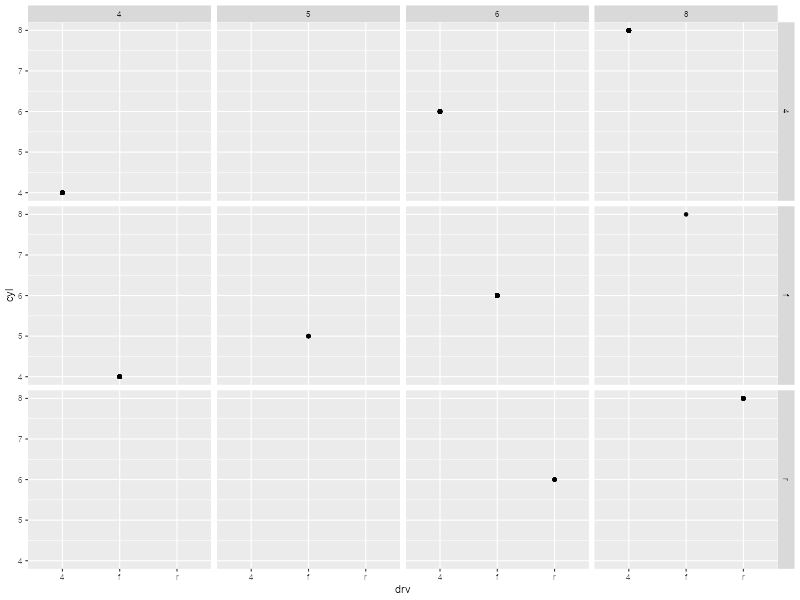

In [45]:
#Exercise 2: What do the empty cells in a plot with facet_grid(drv ~cyl) mean? How do they relate to this plot?
ggplot(data = mpg) + 
  geom_point(mapping = aes(x = drv, y = cyl))+
  facet_grid(drv ~ cyl)
#The empty cells mean there are no points that have that driving style or number of cylinders

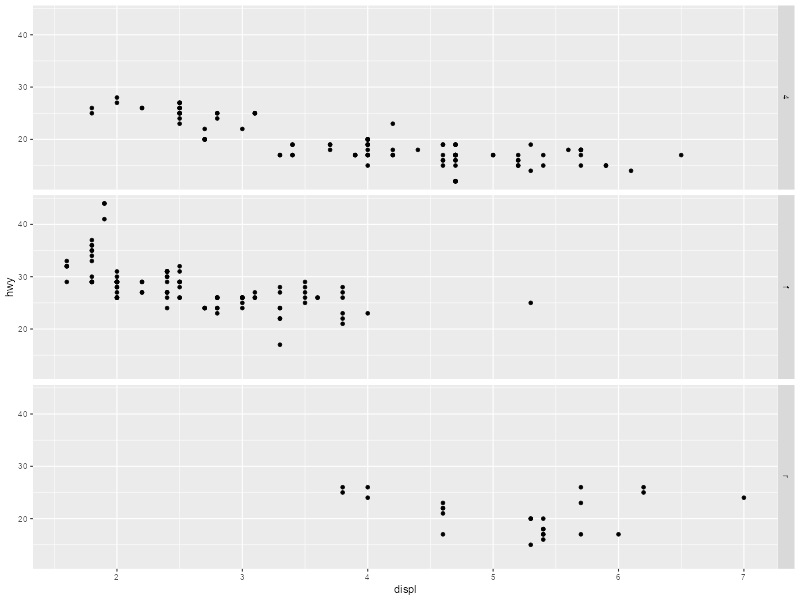

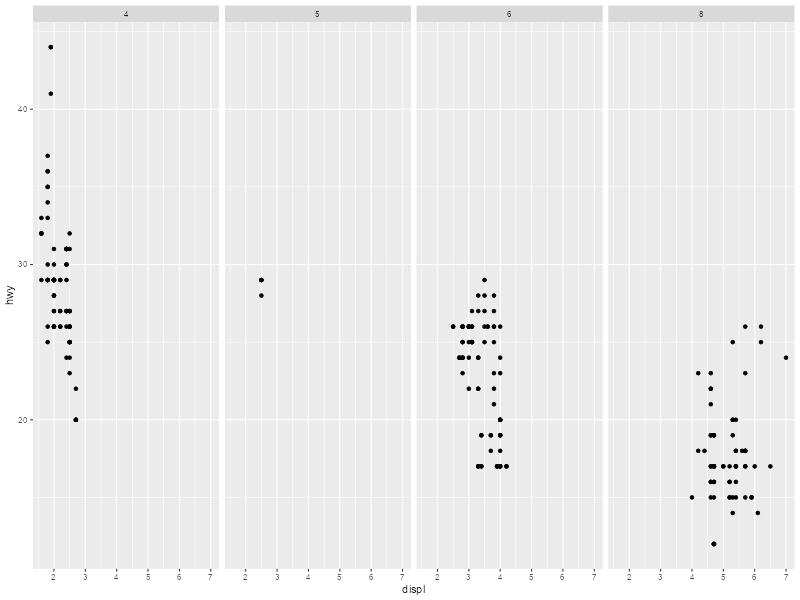

In [ ]:
#Exercise 3: What plots does the following code make? What does . do?
ggplot(data = mpg) +
  geom_point(mapping = aes(x = displ, y = hwy))+
  facet_grid(drv ~ .)
ggplot(data = mpg) +
  geom_point(mapping = aes(x = displ, y = hwy))+
  facet_grid(. ~ cyl)
#The first plot makes a 3x1 grid, with each grid graphing for that drive type. The second makes a 1x4 grid for each cylinder. The . tells it to only use drv or cyl.




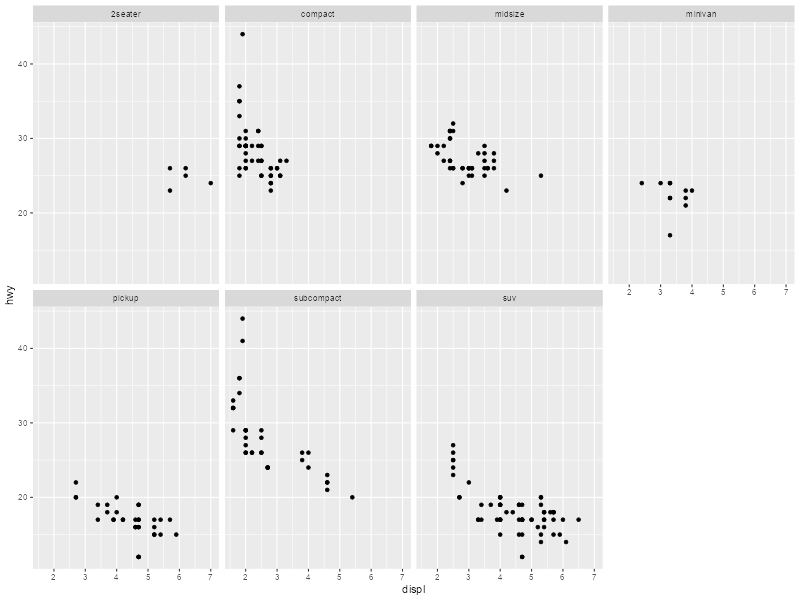

In [50]:
#4. Take the first faceted plot in this section:
ggplot(data = mpg)+
  geom_point(mapping = aes(x = displ, y = hwy))+
  facet_wrap( ~class, nrow = 2)
#What are the advantages to using faceting instead of the color aesthetic? What are the disadvantages? How might the balance change w/ larger dataset?
#Faceting allows for easier comparisons within each facet, while color makes it easier to see the whole trend. With larger datasets, comparisons while using
#one of the approaches which doesn't play to its strengths may become difficult.

In [52]:
#5. Read ?facet_wrap. What does nrow do? What does ncol do? What other options control the layout of the individual panels? Why doesn't facet_grid() have nrow and ncol variables?
?facet_wrap
#ncol gives number of columns, nrow gives number of rows. Other options include scales, space, and shrink. Facet_grid does not have nrow and ncol because 
#these are determined by the variables used in facet_wrap.

In [53]:
#6. When using facet_grid() you should usually put the variable with more unique levels in the columns. Why?
#Because graphs tend to look better with larger x axes than y axes.

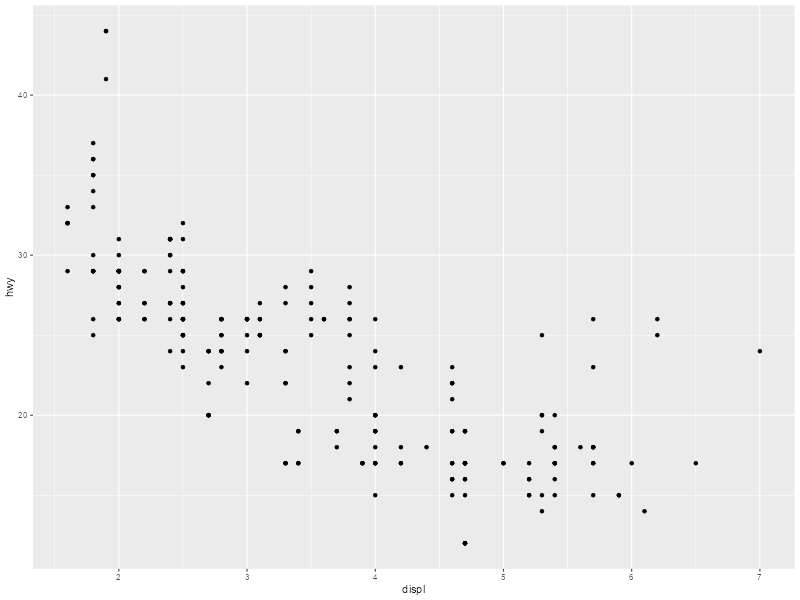

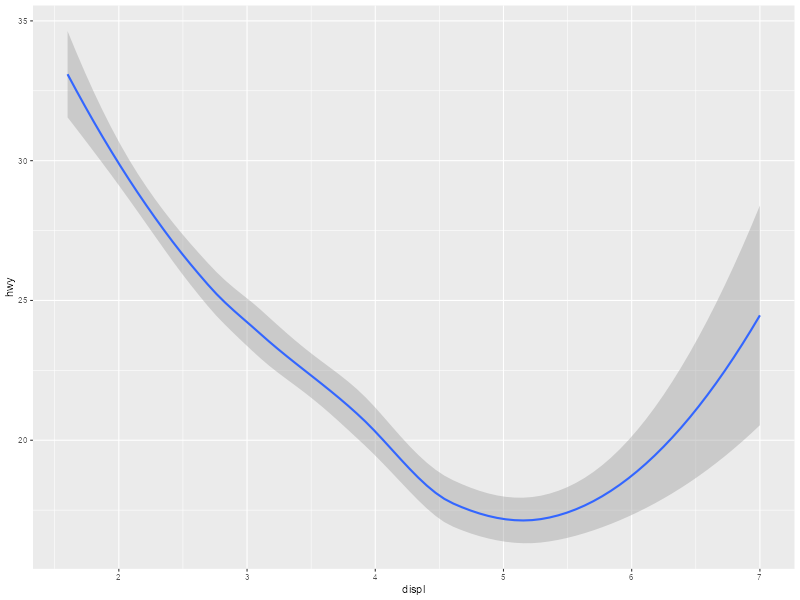

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [55]:
ggplot(data = mpg)+
  geom_point(mapping = aes(x = displ, y= hwy))
ggplot(data = mpg)+
  geom_smooth(mapping = aes(x = displ, y = hwy))

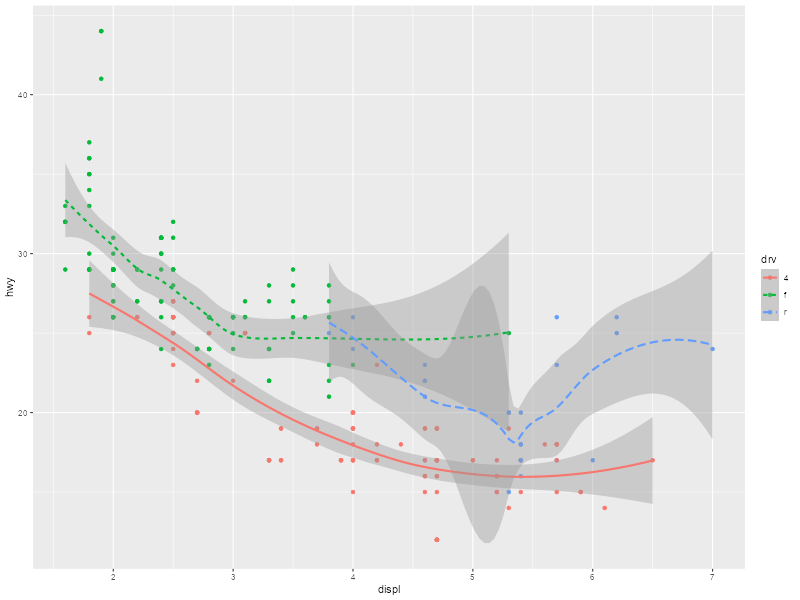

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [61]:
ggplot(data = mpg)+
  geom_point(mapping = aes(x=displ, y = hwy, color = drv))+
  geom_smooth(mapping = aes(x = displ, y = hwy, linetype = drv, color = drv))

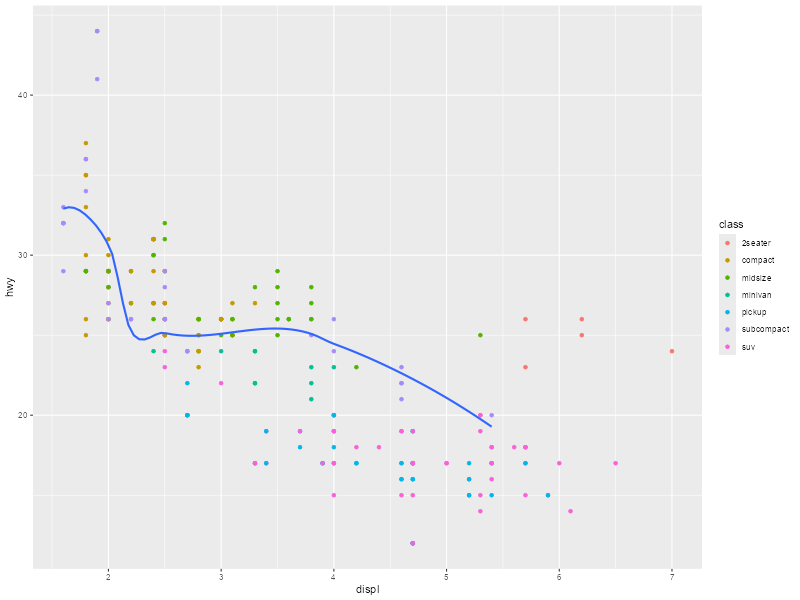

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [66]:
ggplot(data = mpg, mapping = aes(x = displ, y = hwy)) +
  geom_point(mapping = aes(color = class)) +
  geom_smooth(
    data = filter(mpg, class == "subcompact"),
    se = FALSE
  )

Exercises

In [67]:
# 1) What geom would you use to draw a line chart? A boxplot? A histogram? An area chart?
# geom_line(), geom_boxplot(), geom_histogram(), geom_area()

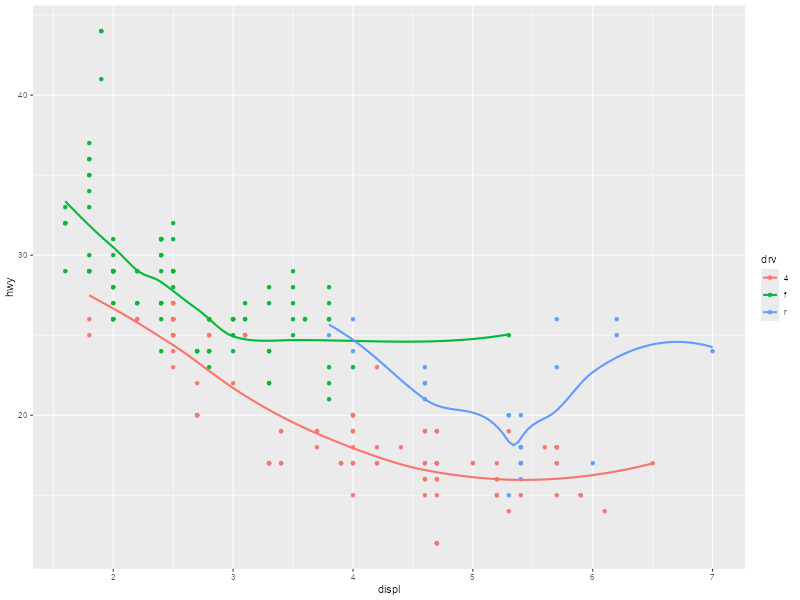

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [ ]:
#2: Run this code in your head and predict what the output will look like. Then, run the code in R and check your predictions.
# I predict the following code will create a plot with displ on the x axis, hwy on the y axis, and drv for color. Each point will be plotted, and there will be a single smooth line for all drv.
ggplot(
  data = mpg,
  mapping = aes(x = displ, y = hwy, color = drv)
) +
  geom_point() +
  geom_smooth(se = FALSE)
#After running the plot, I can see my prediction about the smooth line was incorrect. I predict if I specify a new mapping for the geom_smooth, the output will be what I predicted. 

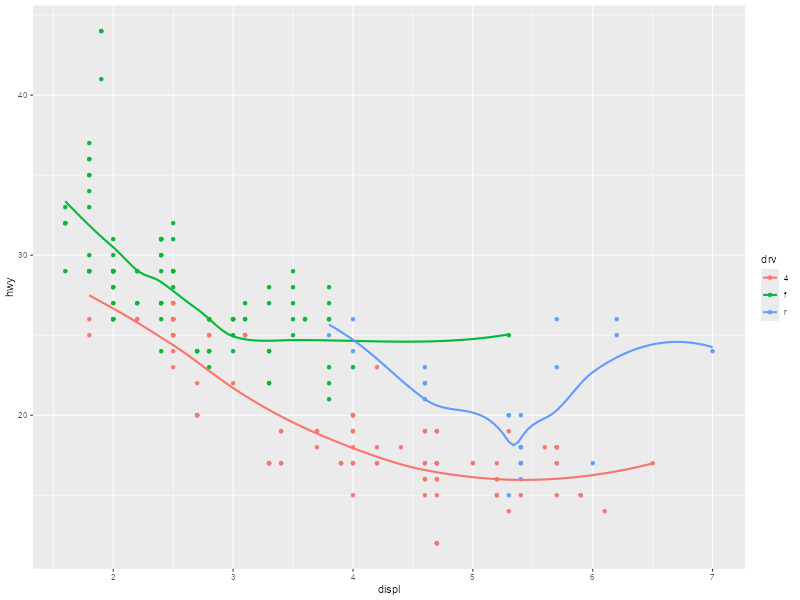

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [ ]:
ggplot(
  data = mpg,
  mapping = aes(x = displ, y = hwy, color = drv)
) +
  geom_point() +
  geom_smooth(mapping = aes(x = displ, y = hwy), se = FALSE)
# This prediction was also wrong. My final prediction is I will not include mapping in the initial ggplot and will instead specify individually in point and smooth

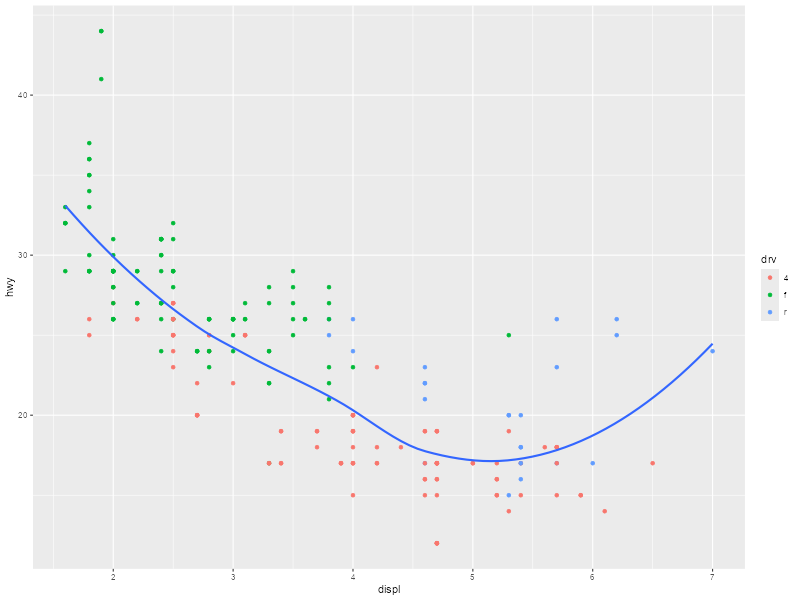

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [73]:
ggplot(
  data = mpg,
) +
  geom_point(mapping = aes(x = displ, y = hwy, color = drv)) +
  geom_smooth( mapping = aes(x = displ, y = hwy), se = FALSE)

In [74]:
#3. What does show.legend = FALSE do? What happens if you remove it? Why do you think I used it earlier in the chapter? Removing it shows a legend, the author removed it because it would create clutter.

In [75]:
#4. What does the se argument to geom_smooth() do?
#se shows the standard error/confidence interval around the smoothed line. 

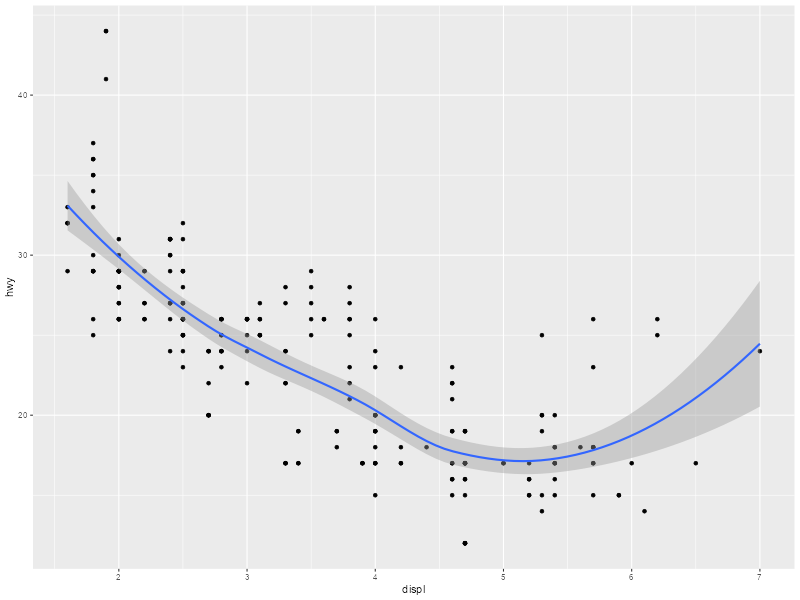

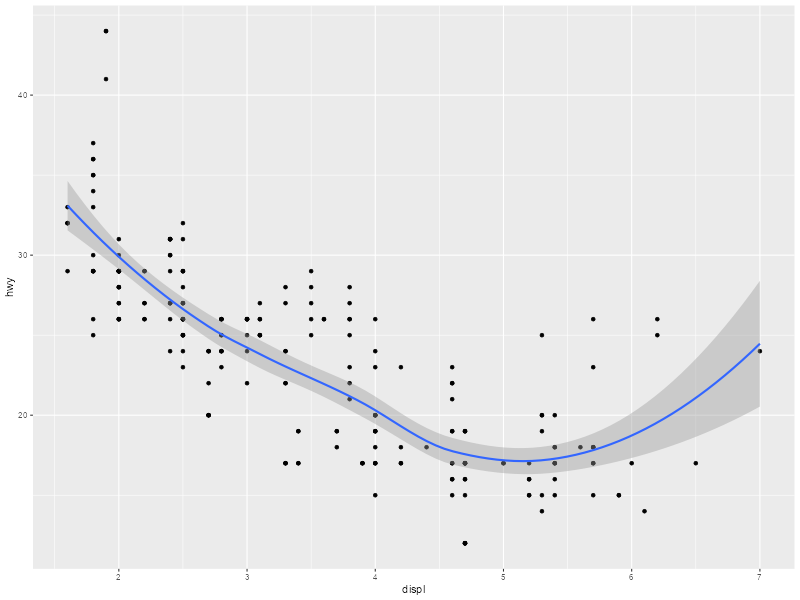

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [79]:
#5. Will these two graphs look different? Why/why not? 
ggplot(data = mpg, mapping = aes(x = displ, y = hwy)) +
  geom_point() + 
  geom_smooth()

ggplot() +
  geom_point(
    data = mpg,
    mapping = aes(x = displ, y = hwy)
  ) +
  geom_smooth(
    data = mpg, 
    mapping = aes(x = displ, y = hwy)
  )
#They will look the same, the only difference is the former calls the data and mapping in the initial ggplot argument and the latter does it for the points and smoothing 

#6. Recreate the R code necessary to generate the following graphs

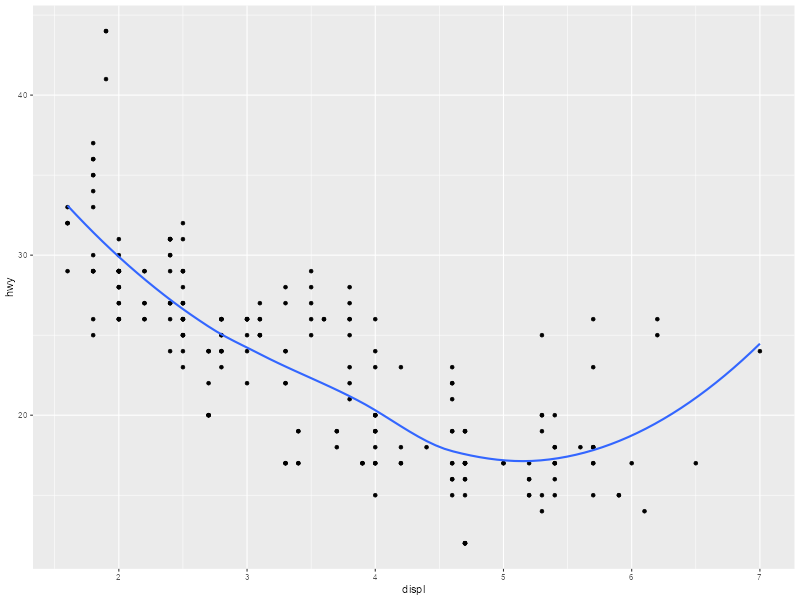

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [80]:
#graph 1:
ggplot(data = mpg, mapping = aes(x = displ, y = hwy))+
  geom_point()+
  geom_smooth(se = FALSE)

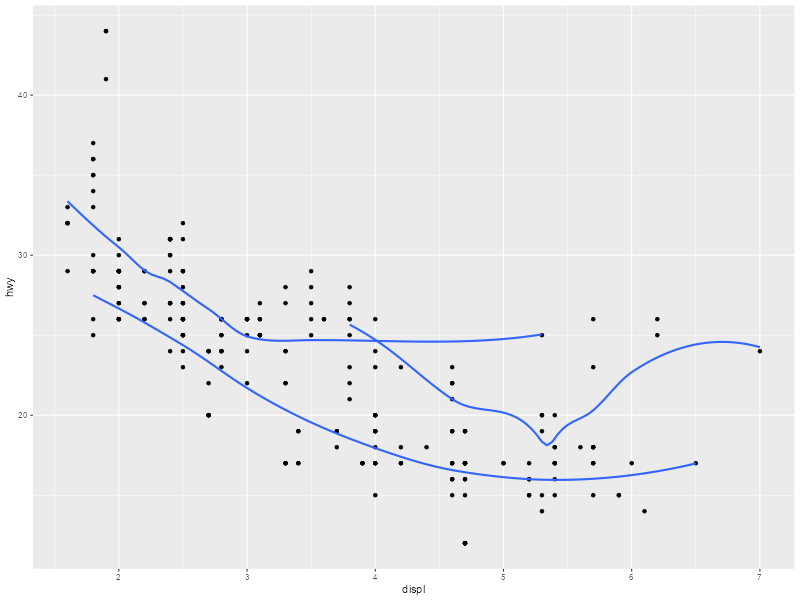

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [81]:
#Graph 2
ggplot()+
  geom_point(data = mpg, mapping = aes(x = displ, y = hwy))+
  geom_smooth(data = mpg, mapping = aes(x = displ, y = hwy, group = drv), se = FALSE)

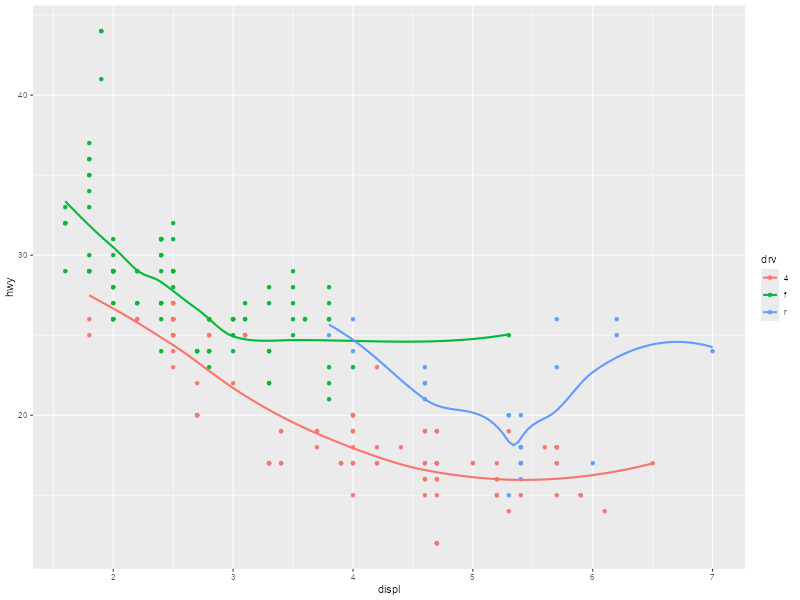

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [82]:
#Graph 3
ggplot(data = mpg, mapping = aes(x = displ, y = hwy, color = drv))+
  geom_point()+
  geom_smooth(se = FALSE)

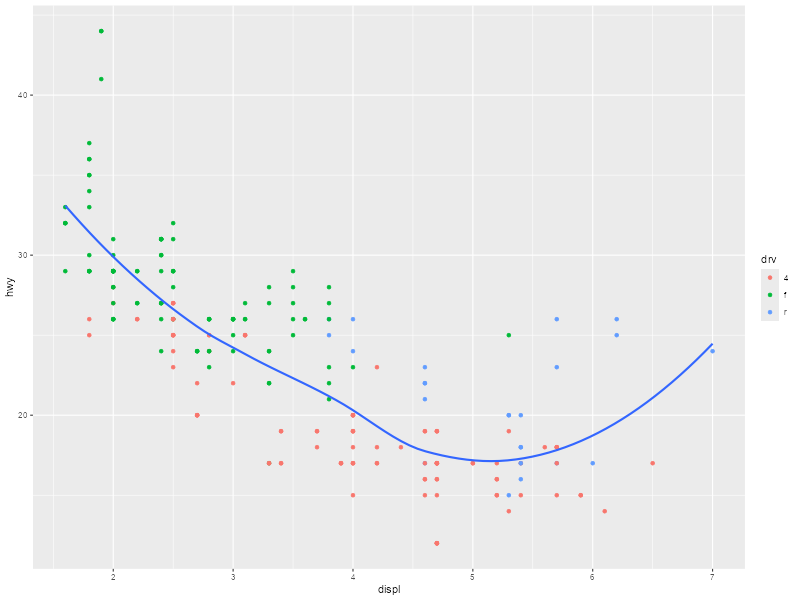

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [83]:
#Graph 4
ggplot()+
  geom_point(data = mpg, mapping = aes(x = displ, y = hwy, color = drv))+
  geom_smooth(data = mpg, mapping = aes(x = displ, y = hwy), se = FALSE)

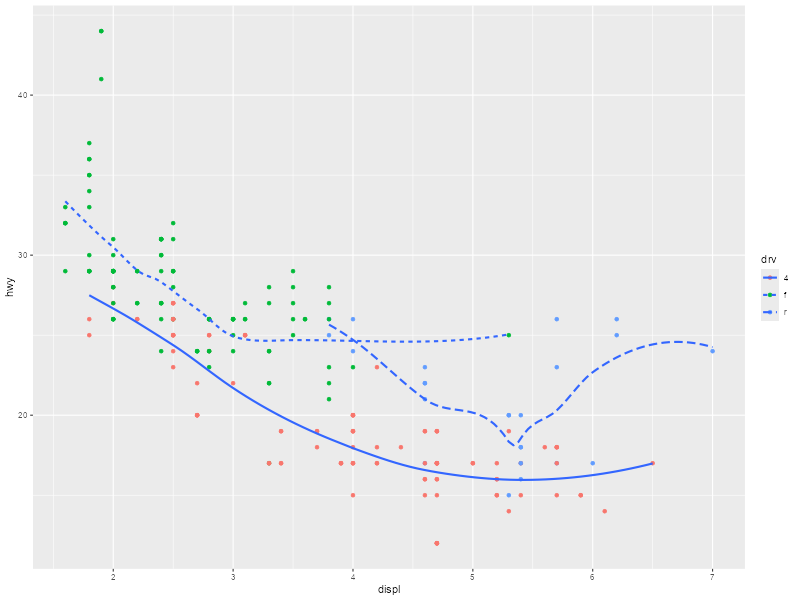

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [84]:
ggplot()+
  geom_point(data = mpg, mapping = aes(x = displ, y = hwy, color = drv))+
  geom_smooth(data = mpg, mapping = aes(x = displ, y = hwy, linetype = drv), se = FALSE)

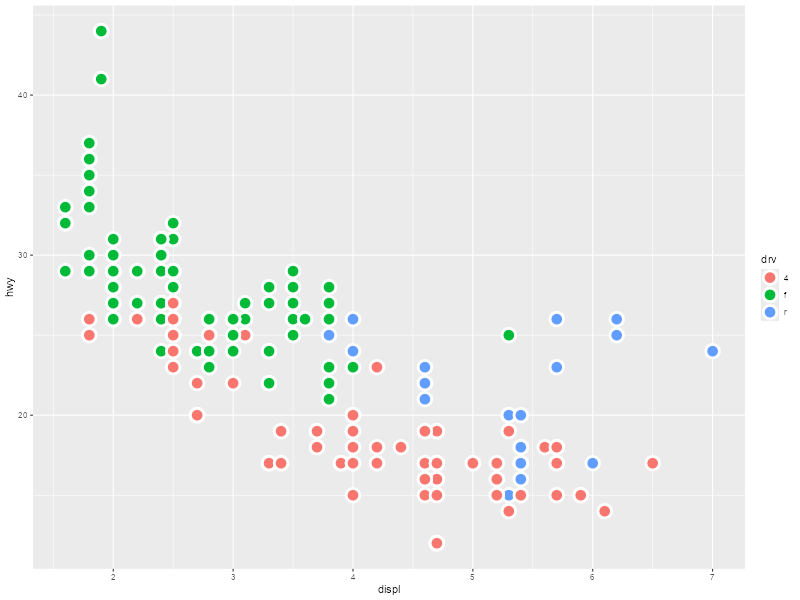

In [93]:
ggplot(data = mpg) +
  geom_point(mapping = aes(x=displ, y=hwy, fill = drv), size = 5, color = 'white', shape =21, stroke = 2)
#Stroke determines the size of the border of a symbol

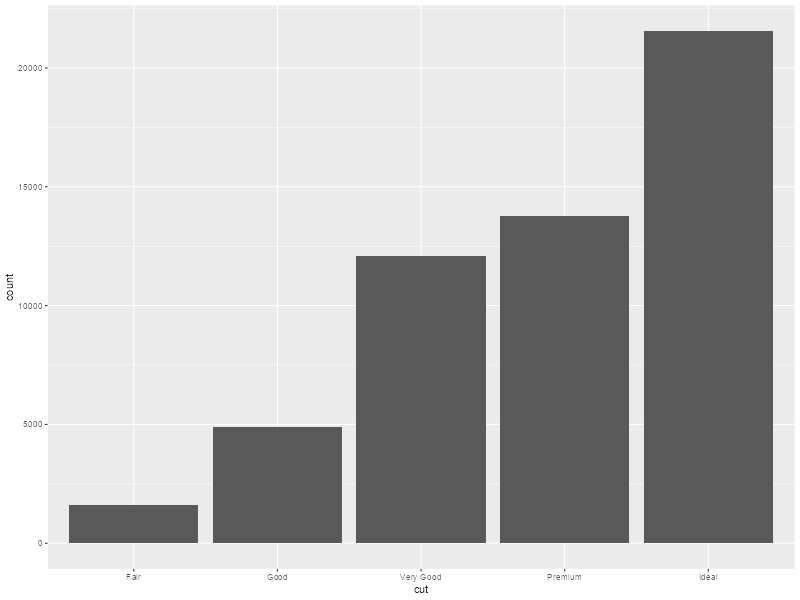

In [94]:
ggplot(data = diamonds)+
  geom_bar(mapping = aes(x = cut))

In [95]:
?geom_bar

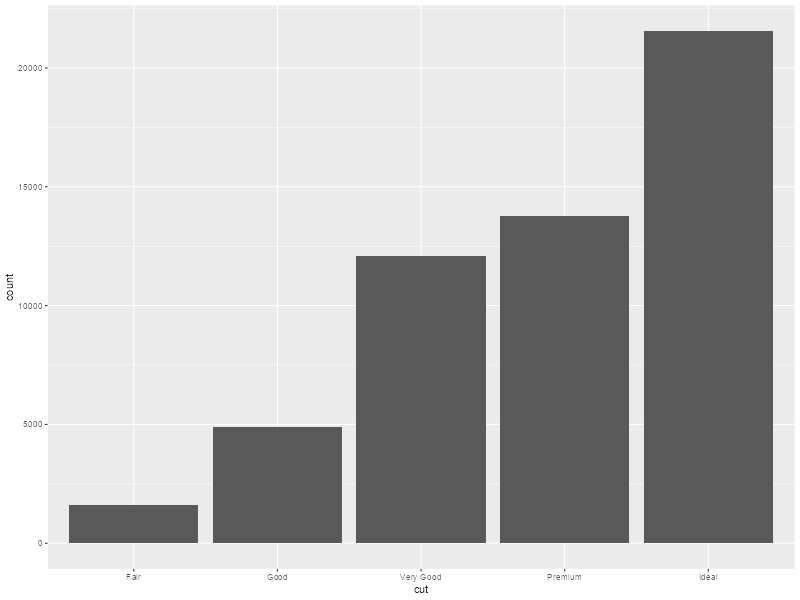

In [96]:
ggplot(data = diamonds)+
  stat_count(mapping = aes(x = cut))

Warning message:
The dot-dot notation (`..prop..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(prop)` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


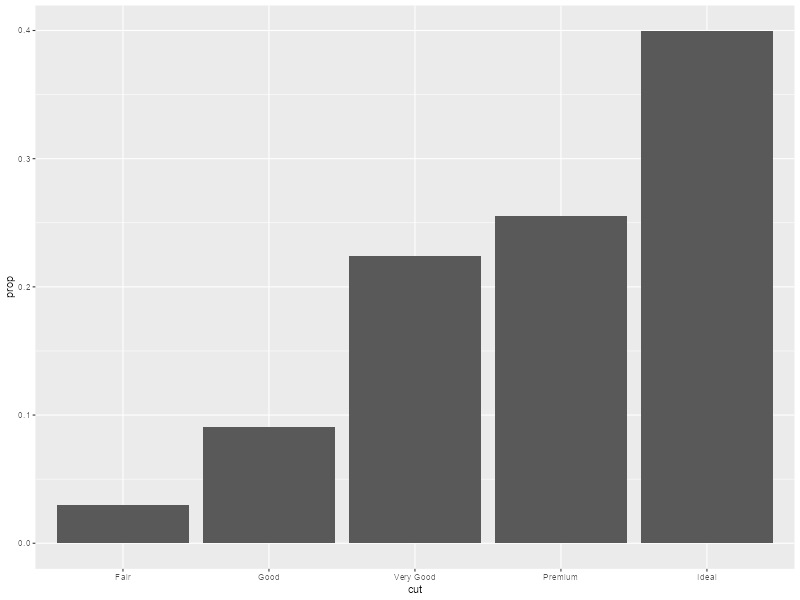

In [97]:
ggplot(data = diamonds)+
  geom_bar(
    mapping = aes(x = cut, y= ..prop.., group = 1)
  )

Warning messages:
1: The `fun.y` argument of `stat_summary()` is deprecated as of ggplot2 3.3.0.
ℹ Please use the `fun` argument instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 
2: The `fun.ymin` argument of `stat_summary()` is deprecated as of ggplot2 3.3.0.
ℹ Please use the `fun.min` argument instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 
3: The `fun.ymax` argument of `stat_summary()` is deprecated as of ggplot2 3.3.0.
ℹ Please use the `fun.max` argument instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


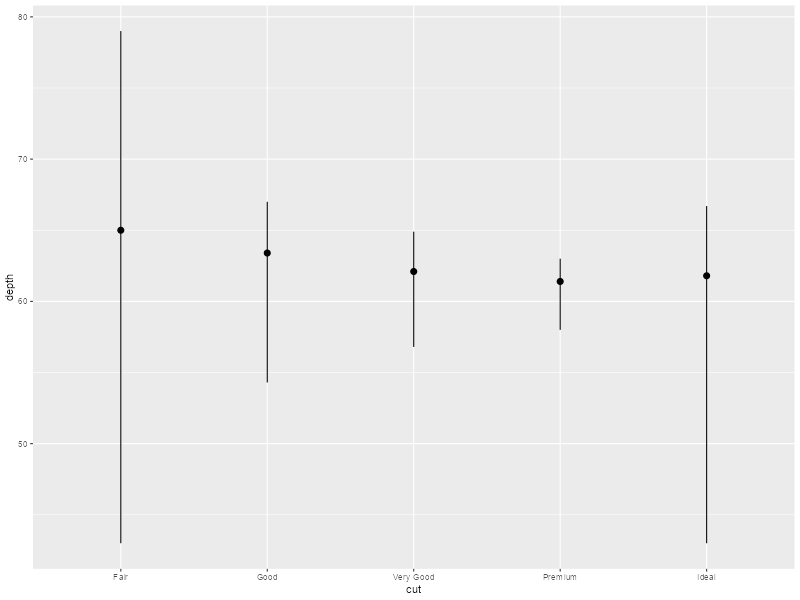

In [98]:
ggplot( data = diamonds)+
  stat_summary(
    mapping = aes( x = cut, y = depth),
    fun.ymin = min,
    fun.ymax = max,
    fun.y = median
  )

Exercises

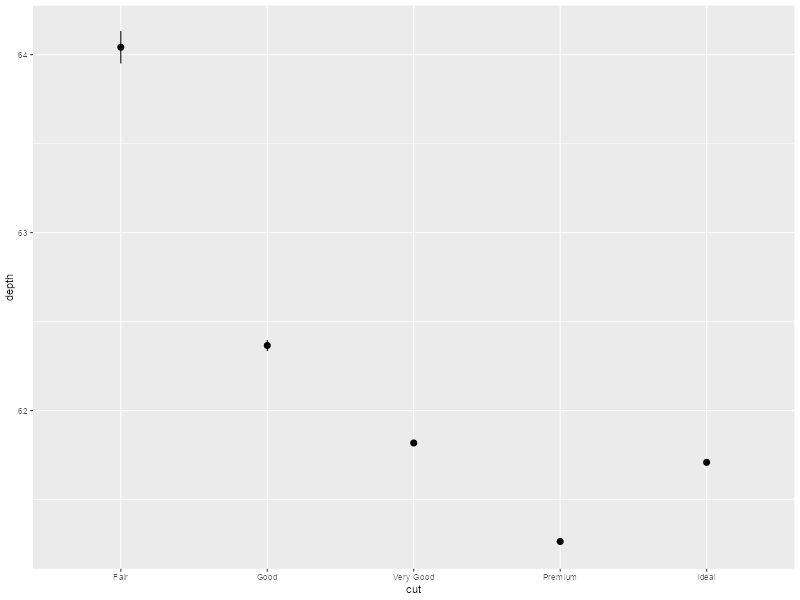

No summary function supplied, defaulting to `mean_se()`

In [100]:
#What is the default geom associated with stat_summary()? How could you rewrite the previous plot to use that geom function instead of the stat function?
#The default geom is pointrange. 
ggplot( data = diamonds)+
  stat_summary(
    mapping = aes( x = cut, y = depth),
  )

In [ ]:
#What does geom_col() do? How is it different to geom_bar?
#geom_col uses another value, rather than count like geom bar, to determine how high the bars go.

In [103]:
#3 Most geoms and stats come in pairs that are almost always used in concert. Read through the documentation and make a list of all the pairs.
#  What do they have in common?
?ggplot

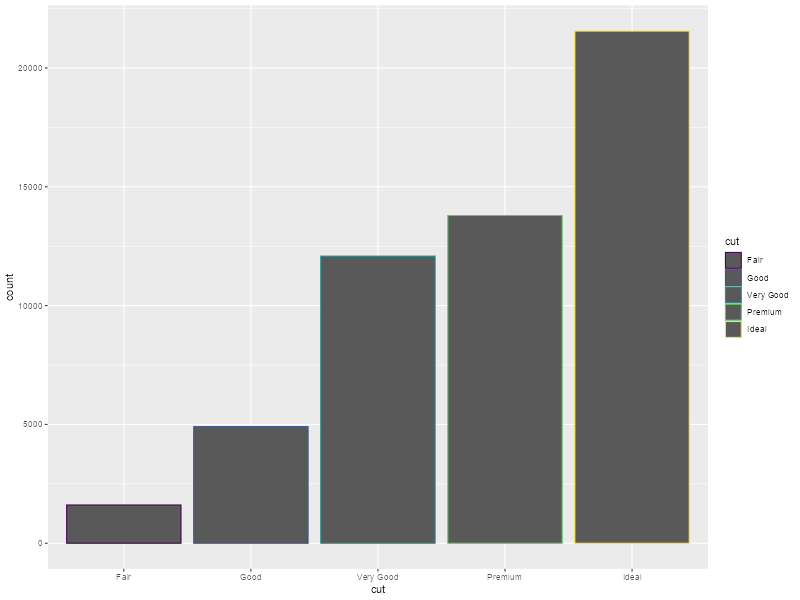

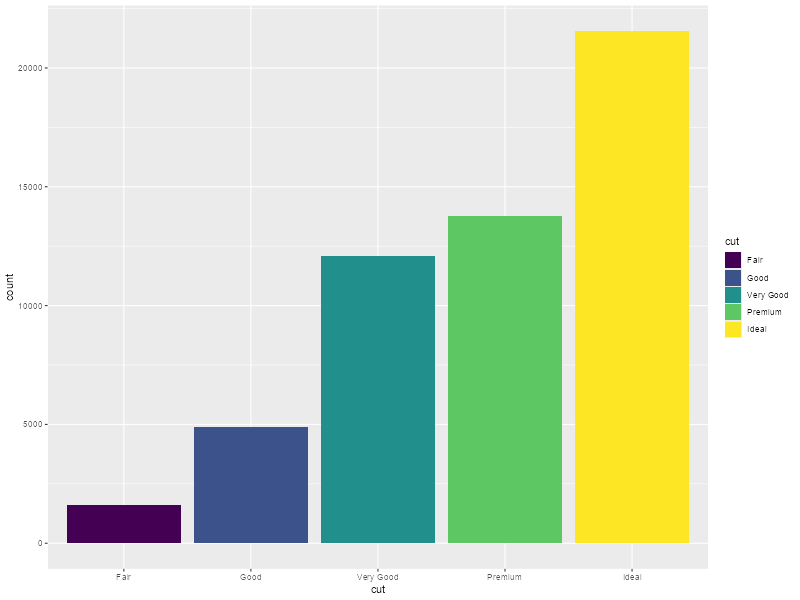

In [104]:
ggplot(data = diamonds)+
  geom_bar(mapping = aes(x = cut, color = cut))
ggplot(data = diamonds)+
  geom_bar(mapping = aes(x = cut, fill = cut))

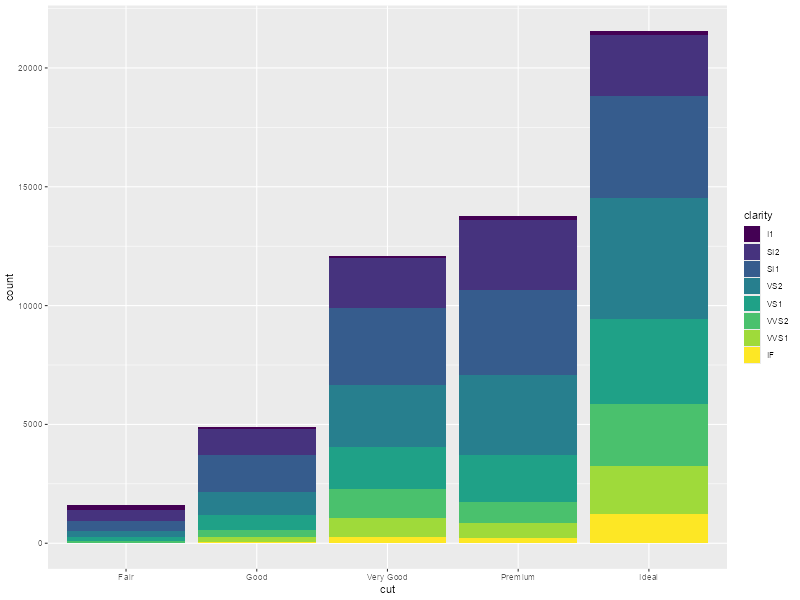

In [105]:
ggplot(data = diamonds)+
  geom_bar(mapping = aes(x = cut, fill = clarity))

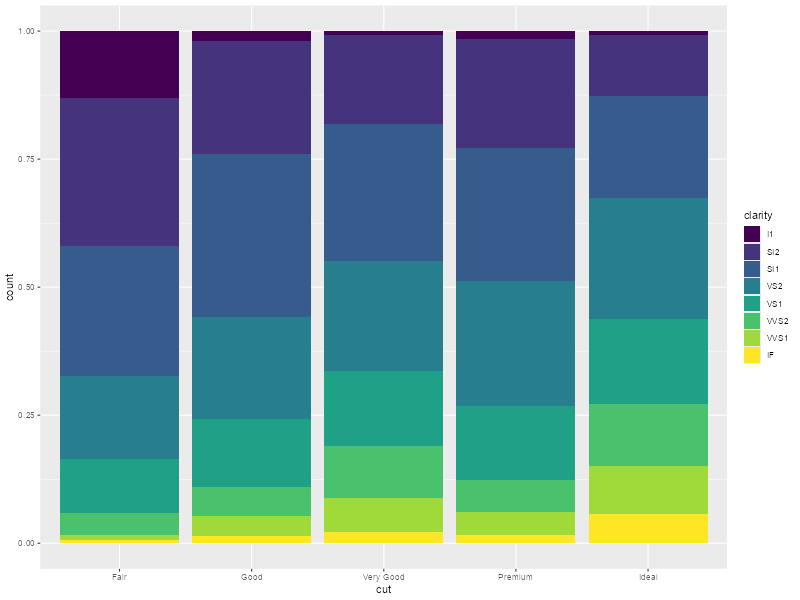

In [109]:
ggplot(data = diamonds) +
  geom_bar(
    mapping = aes(x = cut, fill = clarity),
    position = 'fill'
  )

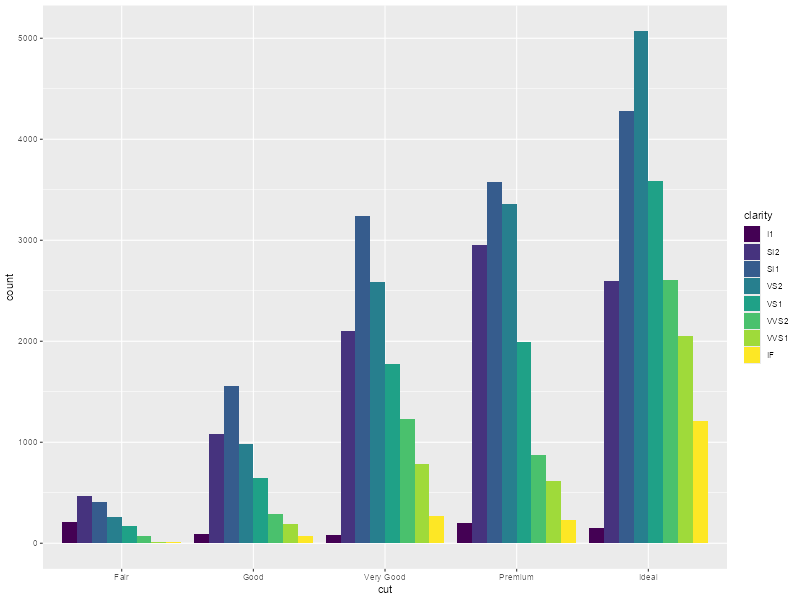

In [110]:
ggplot(data = diamonds) +
  geom_bar(
    mapping = aes(x = cut, fill = clarity),
    position = 'dodge'
  )

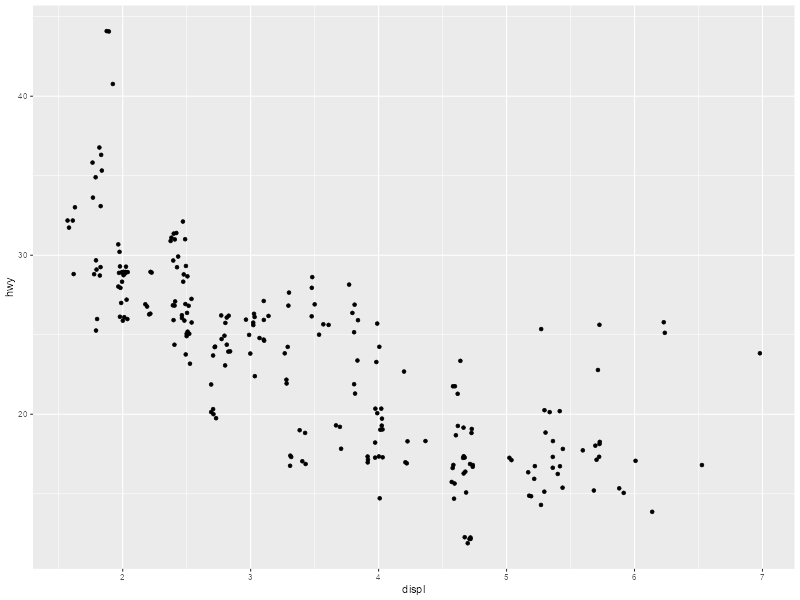

In [111]:
ggplot(data = mpg) + 
  geom_point(
    mapping = aes(x = displ, y= hwy),
    position = 'jitter'
  )

Exercises

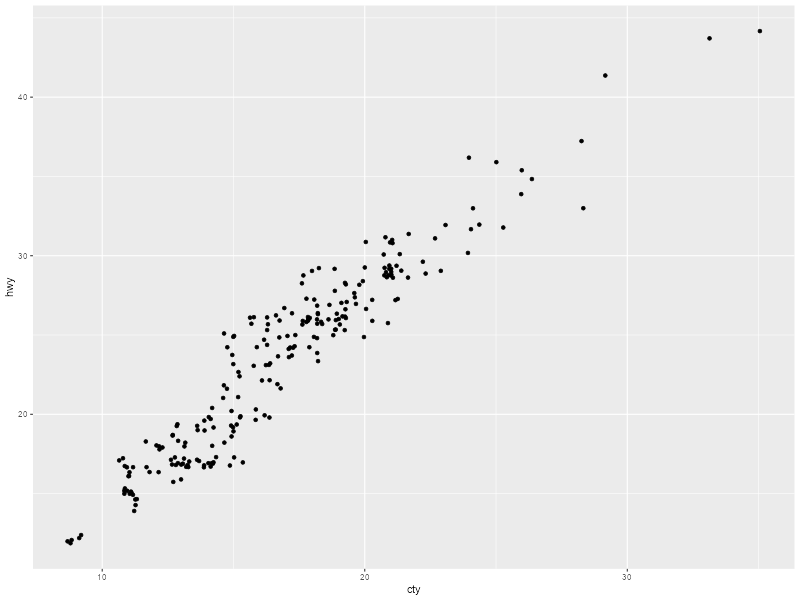

In [113]:
#1. What is the problem with this plot? How could you improve it?
ggplot(data = mpg, mapping = aes(x = cty, y = hwy))+
  geom_jitter()
#The problem is some points have the same cty and hwy values, so the plot does not show all the data. It can be improved by adding a jitter

In [ ]:
#2 What parameters to geom_jitter() control the amount of jittering?
#width and height control the amount of verticle and horizontal jitter

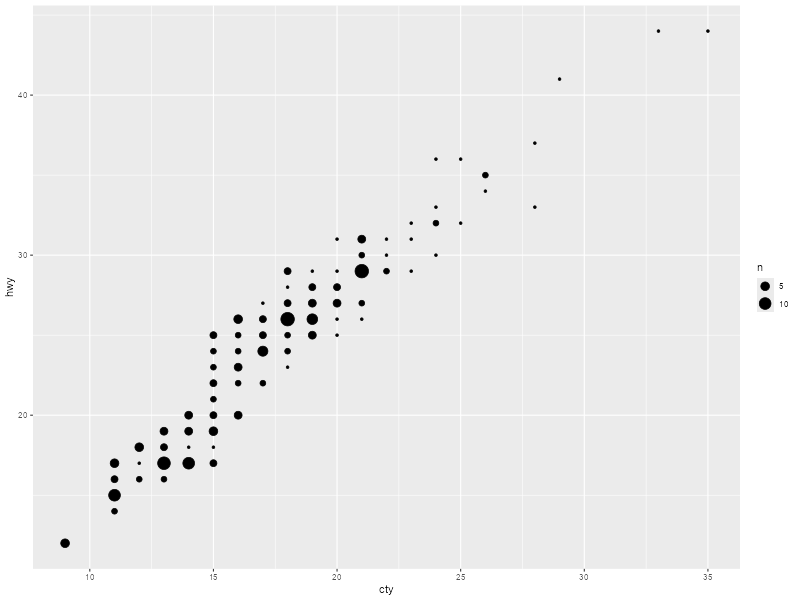

In [ ]:
#3. Compare and contrast geom_jitter() with geom_count()
ggplot(data = mpg, mapping = aes(x = cty, y = hwy))+
  geom_count()
#Both allow you to visualize the amount of points near a value, geom_count does it by changing size (or other) by the number of observations, jitter scatters obs.

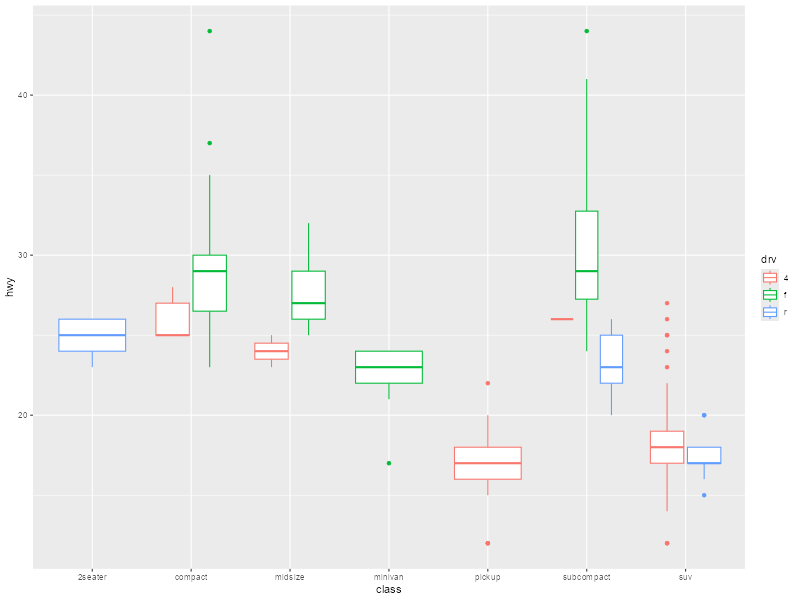

In [117]:
#4. What's the default position argument for geom_boxplot()? Create a visualization of the mpg dataset that demonstrates it.
ggplot(data = mpg, aes(x = class, y = hwy, colour = drv)) +
  geom_boxplot()


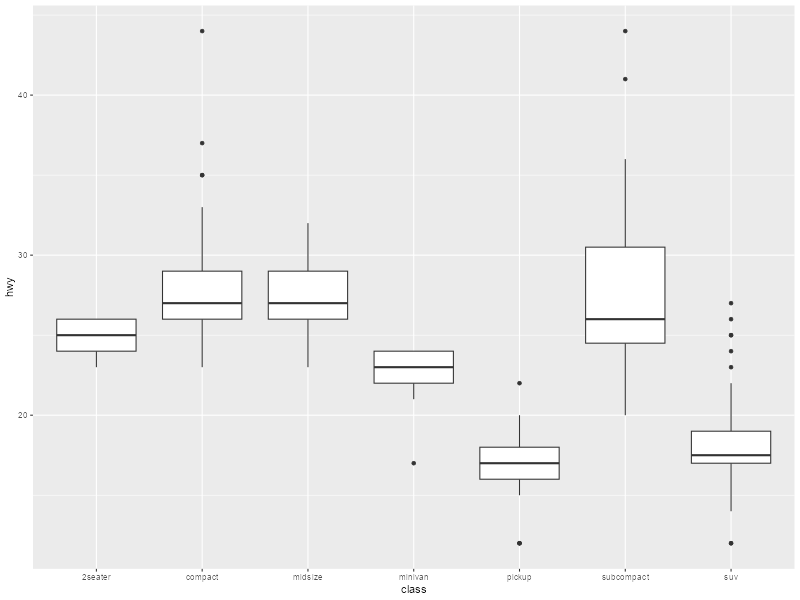

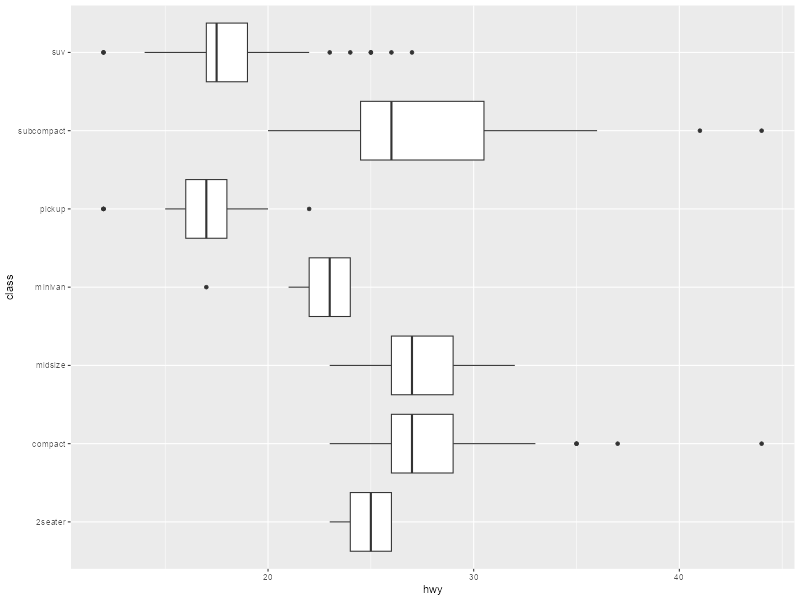

In [118]:
ggplot(data = mpg, mapping = aes(x = class, y = hwy)) +
 geom_boxplot()
ggplot(data = mpg, mapping = aes(x = class, y = hwy)) +
 geom_boxplot() +
 coord_flip()


ℹ The package "maps" is required for `map_data()`.
✖ Would you like to install it?

1: Yes
2: No

Enter an item from the menu, or 0 to exit
Enter an item from the menu, or 0 to exit
Enter an item from the menu, or 0 to exit
Installing package into ‘C:/Users/maxca/AppData/Local/R/win-library/4.5’
(as ‘lib’ is unspecified)


trying URL 'https://cran.rstudio.com/bin/windows/contrib/4.5/maps_3.4.3.zip'
Content type 'application/zip' length 3095858 bytes (3.0 MB)
downloaded 3.0 MB



package ‘maps’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\maxca\AppData\Local\Temp\RtmpMllFZ3\downloaded_packages


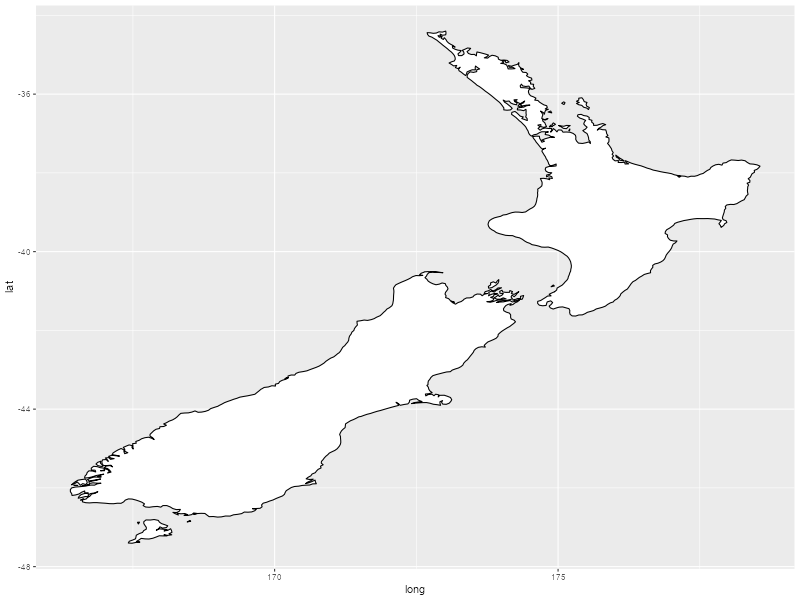

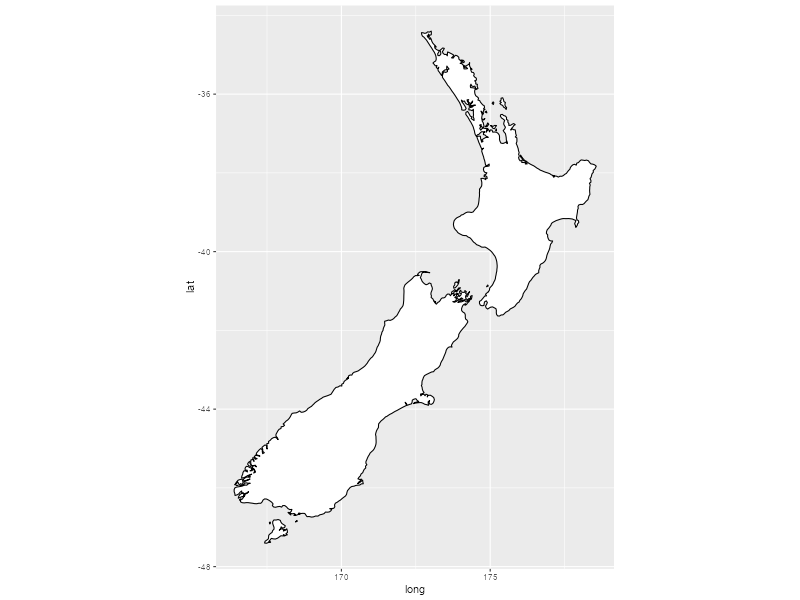

In [119]:
nz <- map_data("nz")
ggplot(nz, aes(long, lat, group = group)) +
 geom_polygon(fill = "white", color = "black")
ggplot(nz, aes(long, lat, group = group)) +
 geom_polygon(fill = "white", color = "black") +
 coord_quickmap()

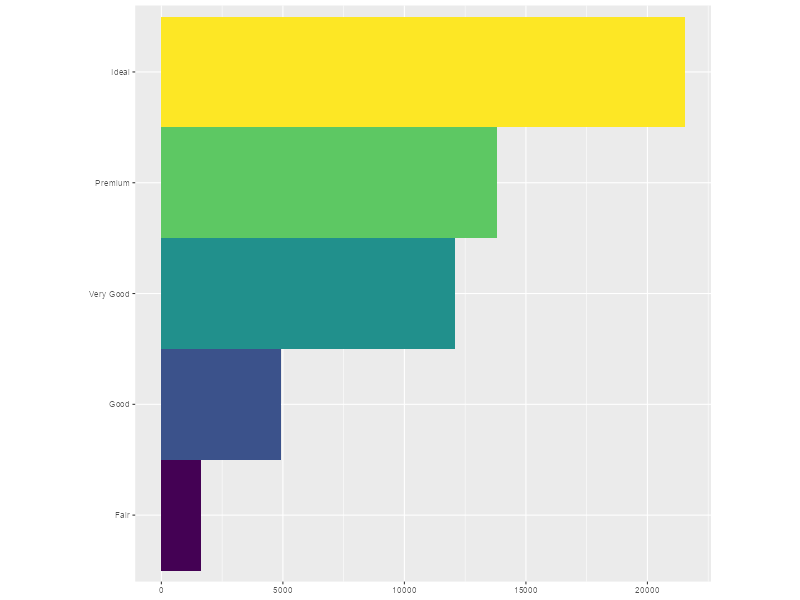

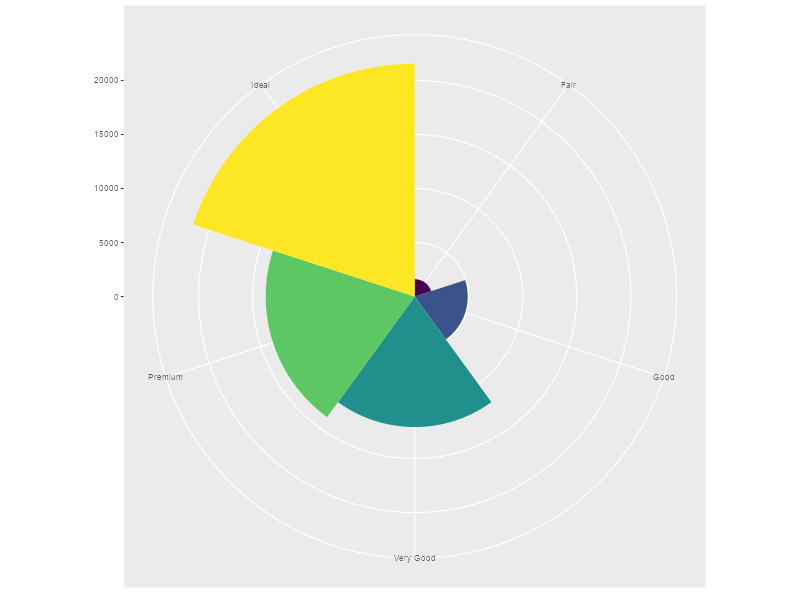

In [120]:
bar <- ggplot(data = diamonds) +
 geom_bar(
 mapping = aes(x = cut, fill = cut),
 show.legend = FALSE,
 width = 1
 ) +
 theme(aspect.ratio = 1) +
 labs(x = NULL, y = NULL)
bar + coord_flip()
bar + coord_polar()
